# 01 - Data Audit and Target Definition
### Lending Club Loan Default Prediction

**Dataset:** LendingClub Issued Loans (2007 to 2018)  
**Source:** [Kaggle, LendingClub Loan Data](https://www.kaggle.com/datasets/wordsforthewise/lending-club)  
**Author:** Talia Low | **Date:** March 2026


**Business Objective**: At loan application / approval time, use the applicant profile to predict whether an accepted **Individual** loan will later become charged-off

This notebook:
- audits the raw accepted-loans dataset
- defines the binary default target
- restricts the sample to resolved loan outcomes
- identifies which fields are usable at origination
- removes clear leakage / post-origination variables
- saves a modeling base table for downstream EDA and modeling

## 1. Setup

In [1]:
import os
import json
import warnings
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

SEED = 42

RAW_DATA_PATH = Path("../data/accepted_2007_to_2018Q4.csv.gz")
OUTPUT_DIR = Path("../data/interim")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Dataset Scope and Modelling Objective

The LendingClub dataset contains detailed records of **every loan issued** through the platform between 2007 and 2018 Q4. Each row represents a single loan application that
was **approved and funded**. The dataset includes:

| Category | Coverage |
|---|---|
| **Loan terms** | Amount, interest rate, instalment, grade, sub-grade, term |
| **Borrower profile** | Income, employment length, home ownership, DTI |
| **Credit bureau snapshot** | FICO score, revolving utilisation, open/total accounts, delinquencies, public records |
| **Geographic context** | State, zip code (first 3 digits) |
| **Loan outcome** | Current status - the basis for our target variable |

**Modelling objective:** Build a binary classifier that predicts, *at the time of loan
origination*, whether a borrower will **default** on the loan - a classic **credit scoring / PD (probability of default)** problem. The model should produce well-calibrated probabilities that can support underwriting decisions.

In [2]:
# Load raw Lending Club accepted loans dataset
# use accepted loan dataset only because it has the labels 
df_raw = pd.read_csv(RAW_DATA_PATH, low_memory=False)

print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
df_raw.head()

Shape: 2,260,701 rows x 151 columns


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

In [3]:
# Standardize column names just in case
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.lower()
)

print(f"Number of columns after standardization: {len(df_raw.columns)}")

Number of columns after standardization: 151


## 2. Target Definition

### 2.1 Loan Status Distribution

In [4]:
status_counts = df_raw['loan_status'].value_counts()
status_pct = (status_counts / len(df_raw) * 100).round(2)

status_df = pd.DataFrame({
    'Count': status_counts,
    'Percent': status_pct
})
status_df.reset_index()

,loan_status,Count,Percent
0,Fully Paid,1076751,47.63
1,Current,878317,38.85
2,Charged Off,268559,11.88
3,Late (31-120 days),21467,0.95
4,In Grace Period,8436,0.37
5,Late (16-30 days),4349,0.19
6,Does not meet the credit policy. Status:Fully ...,1988,0.09
7,Does not meet the credit policy. Status:Charge...,761,0.03
8,Default,40,0.00


### 2.2 Target Mapping
The binary target is defined as follows:

| Loan Status | Target | Rationale |
|---|---|---|
| **Fully Paid** | 0 (non-default) | Loan repaid in full - clear good outcome |
| **Charged Off** | 1 (default) | Lender wrote off the balance - realised credit loss |
| **Default** | 1 (default) | Borrower failed to meet obligations |
| **Late (31-120 days)** | excluded | Outcome still uncertain; including would add label noise |
| **Late (16-30 days)** | excluded | Outcome still uncertain; including would add label noise |
| **Current** | excluded | Loan still active - outcome unknown |
| **In Grace Period** | excluded | Recently missed payment; outcome unknown |
| **Issued** |excluded | Too early to determine outcome |

In [5]:
target_map = {
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
}
# filter only for relevant loan status
df = df_raw[df_raw['loan_status'].isin(target_map.keys())].copy()
df['target'] = df['loan_status'].map(target_map)

### 2.3 Filtering for Individual Loan Type

Since **Individual applications** make up the  98.1% of the dataset and Joint App loans represent a small, structurally different subgroup, this project restricts the **modelling population to Individual applications only**. This keeps the baseline model more homogeneous and easier to interpret

In [6]:
df['application_type'].value_counts(normalize = True)

application_type
Individual    0.980818
Joint App     0.019182
Name: proportion, dtype: float64

In [7]:
df = df.query("application_type == 'Individual'").copy()
df = df.drop(columns=["application_type"])

Imbalance ratio: 4.0:1 (non-default : default)


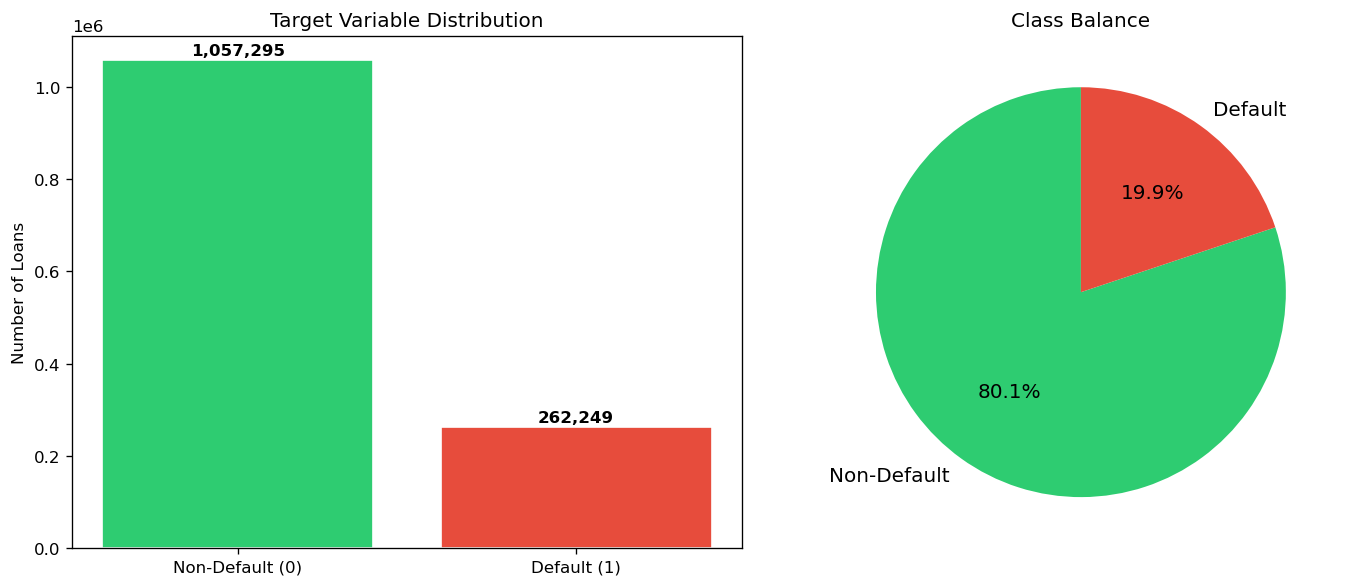

In [8]:
# Visualise target balance
fig, axes = plt.subplots(1, 2, figsize=(12, 5),dpi = 120)

# 1. Bar chart
counts = df['target'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Non-Default (0)', 'Default (1)'], counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Number of Loans')

# 2. Pie chart
axes[1].pie(counts.values, labels=['Non-Default', 'Default'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Balance')

plt.tight_layout()
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1 (non-default : default)")
plt.show()

## 3. Columns Excluded from Modelling
Before exploring the data, we must identify columns that **cannot be used as predictors** because they either   
(a) would not be available at origination/leakage columns,   
(b) are identifiers with no predictive meaning, or   
(c) are redundant with the target

The LendingClub dataset ships with an official data dictionary (`LCDataDictionary.xlsx`), which is referenced in the [Kaggle dataset discussion](https://www.kaggle.com/datasets/wordsforthewise/lending-club/discussion/156484) and mirrored on [Figshare](https://figshare.com/articles/dataset/Lending_club_dataset_description/20016077)

### 3.1 Drop clearly unnecessary columns

In [9]:
# Check whether these columns have values since project is now limited to individual application type

# Identify joint-application-specific columns
joint_app_cols = [
    c for c in df.columns
    if c.startswith("sec_app_") or c in ["annual_inc_joint", "dti_joint",
                                         "verification_status_joint","revol_bal_joint"]
]

joint_na_check = pd.DataFrame({
    "column": joint_app_cols,
    "non_null_count": [df[c].notna().sum() for c in joint_app_cols],
    "missing_count": [df[c].isna().sum() for c in joint_app_cols],
    "missing_pct": [df[c].isna().mean() * 100 for c in joint_app_cols]
}).sort_values("missing_pct", ascending=False)

joint_na_check

,column,non_null_count,missing_count,missing_pct
0,annual_inc_joint,0,1319544,100.0
1,dti_joint,0,1319544,100.0
2,verification_status_joint,0,1319544,100.0
3,revol_bal_joint,0,1319544,100.0
4,sec_app_fico_range_low,0,1319544,100.0
5,sec_app_fico_range_high,0,1319544,100.0
6,sec_app_earliest_cr_line,0,1319544,100.0
7,sec_app_inq_last_6mths,0,1319544,100.0
8,sec_app_mort_acc,0,1319544,100.0
9,sec_app_open_acc,0,1319544,100.0


In [10]:
df.columns.to_list()
df.head(2)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,target
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.0,0.0,4421.723917,4421.72,3600.0,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.0,0.0,25679.660000,25679.66,24700.0,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN

In [11]:
# 1. Identifiers / target / non-predictive text
identifiers_columns = [
    'id',          # Unique loan ID
    'member_id',   # Unique borrower ID
    'url',         # Listing URL
]

target_columns = [
    'loan_status', # Final loan outcome used to derive target
    'target',      # Binary target label created for modelling
]

text_columns = [
    'emp_title',   # Free-text job title
    'desc',        # Free-text borrower description
    'title',       # Free-text loan title
]

admin_columns = [
    'policy_code', # Internal policy code, little business value for modelling
]

# 2. Definite leakage
# These are observed only after the loan has been funded / started performing
leakage_columns = [
    # Current-loan balance / repayment performance
    'pymnt_plan',                # Payment plan status for this loan
    'out_prncp',                 # Outstanding principal remaining
    'out_prncp_inv',             # Outstanding principal attributable to investors
    'total_pymnt',               # Total payments received to date
    'total_pymnt_inv',           # Total payments received by investors
    'total_rec_prncp',           # Principal received to date
    'total_rec_int',             # Interest received to date
    'total_rec_late_fee',        # Late fees received to date

    # Recoveries after default / charge-off
    'recoveries',                # Post charge-off gross recovery
    'collection_recovery_fee',   # Post charge-off collection fee

    # Payment timeline after origination
    'last_pymnt_d',              # Last month payment was received
    'last_pymnt_amnt',           # Last payment amount received
    'next_pymnt_d',              # Next scheduled payment date

    # Refreshed post-origination credit information - refreshed later credit score,not the score available when the loan was first assessed.
    'last_credit_pull_d',        # Most recent month LendingClub pulled credit
    'last_fico_range_high',      # Updated upper FICO range after origination
    'last_fico_range_low',       # Updated lower FICO range after origination

    # Hardship / payment relief
    'hardship_flag',                             # Borrower entered hardship program
    'hardship_type',                             # Type of hardship arrangement
    'hardship_reason',                           # Reason for hardship
    'hardship_status',                           # Current hardship status
    'deferral_term',                             # Length of payment deferral
    'hardship_amount',                           # Reduced payment amount
    'hardship_start_date',                       # Hardship start date
    'hardship_end_date',                         # Hardship end date
    'payment_plan_start_date',                   # Payment plan start date
    'hardship_length',                           # Length of hardship period
    'hardship_dpd',                              # Days past due during hardship
    'hardship_loan_status',                      # Loan status during hardship
    'orig_projected_additional_accrued_interest',# Projected extra accrued interest
    'hardship_payoff_balance_amount',            # Payoff balance under hardship
    'hardship_last_payment_amount',              # Last payment amount during hardship

    # Debt settlement / post-default resolution
    'debt_settlement_flag',      # Whether loan entered debt settlement
    'debt_settlement_flag_date', # Date debt settlement was flagged
    'settlement_status',         # Settlement status
    'settlement_date',           # Settlement date
    'settlement_amount',         # Settlement amount
    'settlement_percentage',     # Settlement amount as percentage of balance
    'settlement_term',           # Settlement term in months
]


all_excluded = set(identifiers_columns + target_columns + text_columns +
                   admin_columns + leakage_columns + 
                   joint_app_cols # not required since only consider individual application
                  )


kept_cols = [c for c in df.columns if c not in all_excluded]

print(f"Total columns in dataset:{len(df.columns)}")
print(f"Columns excluded:{len(all_excluded)}")
print(f"Columns retained for EDA:{len(kept_cols)}")

Total columns in dataset:151
Columns excluded:63
Columns retained for EDA:88


In [12]:
df_keep = df[kept_cols + ['target']].copy()

In [13]:
# Check if further columns need to be dropped
constant_cols = [c for c in df_keep.columns if df_keep[c].nunique(dropna=False) <= 1]

near_constant_cols = []
for c in df_keep.columns:
    vc = df_keep[c].value_counts(dropna=False, normalize=True)
    if len(vc) > 0 and vc.iloc[0] >= 0.995:  
        near_constant_cols.append(c)

print(f"Constant columns: {len(constant_cols)}")
print(constant_cols)

print(f"\nNear-constant columns (top value >= 99.5%): {len(near_constant_cols)}")
near_constant_cols

# acc_now_delinq: Number of accounts on which the borrower is currently delinquent - useful information
# delinq_amnt: Past-due amount owed on the accounts where the borrower is currently delinquent

Constant columns: 0
[]

Near-constant columns (top value >= 99.5%): 2


['acc_now_delinq', 'delinq_amnt']

### 3.2 Run redundancy analysis
After removing clearly ineligible columns, the next step is to check whether any of the retained predictors carry overlapping information

The goal is not to remove variables simply because they are related, but to identify cases where:
- one variable is a more detailed version of another
- two variables are mechanically very similar
- keeping both may add unnecessary redundancy to downstream modelling

The following pairs are reviewed:
- `grade` vs `sub_grade`
- `addr_state` vs `zip_code` using `zip3`
- `fico_range_low` vs `fico_range_high`
- `loan_amnt` vs `funded_amnt` vs `funded_amnt_inv`

In [14]:
# Helper function: compute the proportion of rows where two aligned columns
# have exactly the same value, after excluding missing values
def exact_match_rate(s1, s2):
    # Keep only rows where both values are present
    temp = pd.DataFrame({"s1": s1, "s2": s2}).dropna()
    
    # If no valid rows remain, return missing
    if temp.empty:
        return np.nan
    
    # Compare values row by row.
    # True = match, False = mismatch
    # Taking the mean gives the proportion of exact matches.
    return (temp["s1"] == temp["s2"]).mean()

#### 3.2.1 grade vs sub_grade
`sub_grade` appears to be a more detailed version of `grade`. This checks whether each `sub_grade` maps cleanly into a single `grade`

In [15]:
# Show the distinct mapping between grade and sub_grade
grade_map = (
    df_keep[["grade", "sub_grade"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["grade", "sub_grade"])
)

display(grade_map)
print(f"Number of distinct grade-sub_grade pairs: {len(grade_map)}")

,grade,sub_grade
26,A,A1
8,A,A2
176,A,A3
15,A,A4
59,A,A5
7,B,B1
6,B,B2
43,B,B3
32,B,B4
9,B,B5


Number of distinct grade-sub_grade pairs: 35


> sub_grade is indeed just a more granular version of grade. For the model:
- keep `sub_grade`
- drop `grade`

#### 3.2.3 `addr_state` vs `zip_code` using `zip3`

`zip_code` is more granular than `addr_state`, but it may also be noisier and less stable.To make the comparison more practical, the raw zip code is reduced to its first 3 digits (`zip3`).

In [16]:
# Create zip3 from zip_code for a more stable and interpretable geographic feature.
# Example: '123xx' -> '123'
df_keep["zip3"] = (df_keep["zip_code"]
                   .astype(str)
                   .str.extract(r"(\d{3})", expand=False)
                  )

In [17]:
# Count how many different zip3 values appear within each state.
# A high count means zip3 is more granular than state.
zip3_per_state = (
    df_keep[["addr_state", "zip3"]]
    .dropna()
    .groupby("addr_state")["zip3"]
    .nunique()
    .rename("n_zip3_per_state")
    .reset_index()
    .sort_values("n_zip3_per_state", ascending=False)
)
zip3_per_state

,addr_state,n_zip3_per_state
4,CA,158
43,TX,138
34,NY,134
9,FL,112
38,PA,94
14,IL,91
45,VA,90
27,NC,78
19,MA,66
31,NJ,65


In [18]:
# Show samples of the state vs zip3 combinations
state_zip_sample = (
    df_keep[["addr_state", "zip3"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["addr_state", "zip3"])
)

In [19]:
state_zip_sample

,addr_state,zip3
2259906,AK,025
1060251,AK,112
1259650,AK,300
1874490,AK,314
1649250,AK,352
...,...,...
28162,WY,831
1016222,WY,834
363934,WY,862
547320,WY,980


In [20]:
# Number of zip3 values within each state
if {"addr_state", "zip3"}.issubset(df_keep.columns):
    zip3_per_state = (
        df_keep[["addr_state", "zip3"]]
        .dropna()
        .groupby("addr_state")["zip3"]
        .nunique()
        .rename("n_zip3_per_state")
        .reset_index()
        .sort_values("n_zip3_per_state", ascending=False)
    )
    display(zip3_per_state.head(20))

,addr_state,n_zip3_per_state
4,CA,158
43,TX,138
34,NY,134
9,FL,112
38,PA,94
14,IL,91
45,VA,90
27,NC,78
19,MA,66
31,NJ,65


#### 3.2.4 `fico_range_low` vs `fico_range_high`

These two fields describe the borrower's FICO score range at origination.  
The objective here is to check whether they are so similar that they can be replaced by a single summary measure.

In [21]:
# Compare the lower and upper FICO range values.
fico_temp = df_keep[["fico_range_low", "fico_range_high"]].dropna().copy()

# Compute the difference and average between the two FICO fields.
fico_temp["fico_diff"] = fico_temp["fico_range_high"] - fico_temp["fico_range_low"]
fico_temp["fico_avg"] = (fico_temp["fico_range_low"] + fico_temp["fico_range_high"]) / 2
fico_temp['fico_diff'].value_counts()

fico_diff
4.0    1319371
5.0        173
Name: count, dtype: int64

In [22]:
# fico_temp.query("fico_diff == 5")

In [23]:
# Summarize how similar the 2 FICO columns are.
fico_summary = pd.DataFrame({
    "metric": [
        "rows_used",
        "pearson_corr",
        "exact_match_rate",
        "mean_diff_high_minus_low",
        "median_diff_high_minus_low",
        "min_diff_high_minus_low",
        "max_diff_high_minus_low"
    ],
    "value": [
        len(fico_temp),
        fico_temp[["fico_range_low", "fico_range_high"]].corr().iloc[0, 1],
        exact_match_rate(fico_temp["fico_range_low"], fico_temp["fico_range_high"]),
        fico_temp["fico_diff"].mean(),
        fico_temp["fico_diff"].median(),
        fico_temp["fico_diff"].min(),
        fico_temp["fico_diff"].max()
    ]
})

fico_summary.round(2)

,metric,value
0,rows_used,1319544.0
1,pearson_corr,1.0
2,exact_match_rate,0.0
3,mean_diff_high_minus_low,4.0
4,median_diff_high_minus_low,4.0
5,min_diff_high_minus_low,4.0
6,max_diff_high_minus_low,5.0


Since the 2 columns are almost perfectly correlated and differ only by a small fixed range, they can be replaced by a single variable such as `fico_avg`. For the model:
- create `fico_avg`
- drop `fico_range_low` and `fico_range_high`

In [24]:
# # Create a single average FICO feature for later use
# df_keep["fico_avg"] = (df_keep["fico_range_low"] + df_keep["fico_range_high"]) / 2

#### 3.2.5 `loan_amnt` vs `funded_amnt` vs `funded_amnt_inv`

These 3 columns all describe the size of the loan, but from slightly different angles:
- `loan_amnt`: requested loan amount by the borrower
- `funded_amnt`: amount funded by LendingClub
- `funded_amnt_inv`: amount funded by investors 

This section checks whether they are similar enough that keeping all three would be redundant.

In [25]:
# Correlation matrix for the three loan amount variables.
amount_cols = ["loan_amnt", "funded_amnt", "funded_amnt_inv"]
amount_corr = df_keep[amount_cols].corr()

amount_corr.round(4)

,loan_amnt,funded_amnt,funded_amnt_inv
loan_amnt,1.0000,0.9995,0.9985
funded_amnt,0.9995,1.0000,0.9991
funded_amnt_inv,0.9985,0.9991,1.0000


In [26]:
# Check exact row-by-row match rates between the amount fields.
print("loan_amnt vs funded_amnt exact match rate:",
      round(exact_match_rate(df_keep["loan_amnt"], df_keep["funded_amnt"]) * 100, 2), "%")

print("loan_amnt vs funded_amnt_inv exact match rate:",
      round(exact_match_rate(df_keep["loan_amnt"], df_keep["funded_amnt_inv"]) * 100, 2), "%")

print("funded_amnt vs funded_amnt_inv exact match rate:",
      round(exact_match_rate(df_keep["funded_amnt"], df_keep["funded_amnt_inv"]) * 100, 2), "%")

loan_amnt vs funded_amnt exact match rate: 99.85 %
loan_amnt vs funded_amnt_inv exact match rate: 91.42 %
funded_amnt vs funded_amnt_inv exact match rate: 91.45 %


In [27]:
# Check the absolute differences between these amount fields.
amount_diff_summary = pd.DataFrame({
    "comparison": [
        "loan_amnt vs funded_amnt",
        "loan_amnt vs funded_amnt_inv",
        "funded_amnt vs funded_amnt_inv"
    ],
    "mean_abs_diff": [
        (df_keep["loan_amnt"] - df_keep["funded_amnt"]).abs().mean(),
        (df_keep["loan_amnt"] - df_keep["funded_amnt_inv"]).abs().mean(),
        (df_keep["funded_amnt"] - df_keep["funded_amnt_inv"]).abs().mean()
    ],
    "median_abs_diff": [
        (df_keep["loan_amnt"] - df_keep["funded_amnt"]).abs().median(),
        (df_keep["loan_amnt"] - df_keep["funded_amnt_inv"]).abs().median(),
        (df_keep["funded_amnt"] - df_keep["funded_amnt_inv"]).abs().median()
    ],
    "max_abs_diff": [
        (df_keep["loan_amnt"] - df_keep["funded_amnt"]).abs().max(),
        (df_keep["loan_amnt"] - df_keep["funded_amnt_inv"]).abs().max(),
        (df_keep["funded_amnt"] - df_keep["funded_amnt_inv"]).abs().max()
    ]
})

amount_diff_summary

,comparison,mean_abs_diff,median_abs_diff,max_abs_diff
0,loan_amnt vs funded_amnt,8.579706,0.0,21150.000000
1,loan_amnt vs funded_amnt_inv,31.306603,0.0,32474.996081
2,funded_amnt vs funded_amnt_inv,22.726897,0.0,32474.996081


**Interpretation**

These amount fields are almost identical, then keeping all three is unnecessary.
For the baseline model:
- keep `loan_amnt` as the main amount variable
- drop `funded_amnt` and `funded_amnt_inv` if they add little distinct information

Additionally since funded_amnt and funded_amnt_inv reflect downstream funding commitments which also make them less suitable for a clean origination-stage baseline model

In [28]:
# Drop redundant columns identified in the analysis above
# Keep zip3 as the reduced geographic feature and drop raw zip_code

# Create a single average FICO feature for later use
df_keep["fico_avg"] = (df_keep["fico_range_low"] + df_keep["fico_range_high"]) / 2

drop_due_to_redundancy = [
    "grade",
    "fico_range_low",
    "fico_range_high",
    "funded_amnt",
    "funded_amnt_inv",
    "zip_code",
]

df_keep = df_keep.drop(columns=drop_due_to_redundancy, errors="ignore").copy()

print(f"Columns remaining after redundancy analysis: {len(df_keep.columns)}")

Columns remaining after redundancy analysis: 85


## 4. Data Quality Observations
examines the **data types, value ranges, and anomalies** in the retained columns

### 4.1 Summary statistics 

In [29]:
print(f"Retained dataset shape: {df_keep.shape[0]:,} rows x {df_keep.shape[1]:,} columns")
df_keep.head()

Retained dataset shape: 1,319,544 rows x 85 columns


,loan_amnt,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,target,zip3,fico_avg
0,3600.0,36 months,13.99,123.03,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,debt_consolidation,PA,5.91,0.0,Aug-2003,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.0,30.0,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,0,190,677.0
1,24700.0,36 months,11.99,820.28,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,small_business,SD,16.06,1.0,Dec-1999,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.0,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,0,577,717.0
4,10400.0,60 months,22.45,289.91,F1,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,major_purchase,PA,25.37,1.0,Jun-1998,3.0,12.0,NaN,12.0,0.0,21929.0,64.5,35.0,w,0.0,NaN,0.0,0.0,331730.0,1.0,3.0,0.0,3.0,14.0,73839.0,84.0,4.0,7.0,9702.0,78.0,34000.0,2.0,1.0,3.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,12.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,0,174,697.0
5,11950.0,36 months,13.44,405.18,C3,4 years,RENT,34000.0,Source Verified,Dec-2015,debt_consolidation,GA,10.20,0.0,Oct-1987,0.0,NaN,NaN,5.0,0.0,8822.0,68.4,6.0,w,0.0,NaN,0.0,0.0,12798.0,0.0,1.0,0.0,0.0,338.0,3976.0,99.0,0.0,0.0,4522.0,76.0,12900.0,0.0,0.0,0.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,NaN,NaN,NaN,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,Cash,0,300,692.0
6,20000.0,36 months,9.17,637.58,B2,10+ years,MORTGAGE,180000.0,Not Verified,Dec-2015,debt_consolidation,MN,14.67,0.0,Jun-1990,0.0,49.0,NaN,12.0,0.0,87329.0,84.5,27.0,f,0.0,NaN,0.0,0.0,360358.0,0.0,2.0,0.0,2.0,18.0,29433.0,63.0,2.0,3.0,13048.0,74.0,94200.0,1.0,0.0,1.0,6.0,30030.0,0.0,102.9,0.0,0.0,142.0,306.0,10.0,10.0,4.0,12.0,NaN,10.0,NaN,0.0,4.0,6.0,4.0,5.0,7.0,9.0,16.0,6.0,12.0,0.0,0.0,0.0,2.0,96.3,100.0,0.0,0.0,388852.0,116762.0,31500.0,46452.0,Cash,0,550,682.0


In [30]:
dtype_summary = df_keep.dtypes.value_counts()
print("Data types in retained columns:")
print(dtype_summary.to_string())

# Identify numeric vs categorical
numeric_cols = df_keep.select_dtypes(include=[np.number]).columns.tolist()
if 'target' in numeric_cols:
    numeric_cols.remove('target')
cat_cols = df_keep.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_cols)}")
print(f"Numeric features: {numeric_cols}")
print()  # line break
print(f"Categorical features: {len(cat_cols)}")
print(f"Categorical columns: {cat_cols}")

Data types in retained columns:
float64    72
object     12
int64       1
Numeric features: 72
Numeric features: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_12

In [31]:
# Distribution of key numeric features 
key_numeric = [
    'loan_amnt',       # Loan amount applied for by the borrower
    'int_rate',        # Interest rate on the loan
    'installment',     # Monthly repayment amount if the loan originates
    'annual_inc',      # Borrower's self-reported annual income
    'dti',             # Debt-to-income ratio excluding mortgage and requested LC loan
    'fico_avg',  # Average of lower and upper bound of borrower's FICO score range at origination
    'revol_bal',       # Total revolving credit balance
    'revol_util',      # Revolving credit utilization rate
    'open_acc',        # Number of open credit lines
    'total_acc',       # Total number of credit lines in borrower's file
    'mort_acc',        # Number of mortgage accounts
    'pub_rec',         # Number of derogatory public records
    'delinq_2yrs',     # Number of 30+ days past-due delinquencies in past 2 years
    'inq_last_6mths'   # Number of credit inquiries in past 6 months, excluding auto/mortgage
]

stats = df_keep[key_numeric].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
stats.round(1)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
loan_amnt,1319544.0,14330.6,8659.1,500.0,1500.0,3200.0,7800.0,12000.0,20000.0,32100.0,35000.0,40000.0
int_rate,1319544.0,13.2,4.7,5.3,5.3,6.5,9.8,12.7,16.0,22.0,26.3,31.0
installment,1319544.0,435.6,259.8,4.9,52.7,108.3,247.4,373.2,576.5,956.4,1217.1,1719.8
annual_inc,1319544.0,76609.9,70335.7,2000.0,18953.9,28000.0,46000.0,65000.0,90756.2,156000.0,255000.0,10999200.0
dti,1319544.0,18.0,8.4,-1.0,1.8,5.0,11.8,17.5,23.9,32.6,37.4,50.0
fico_avg,1319544.0,698.0,31.7,627.0,662.0,662.0,672.0,692.0,712.0,762.0,802.0,847.5
revol_bal,1319544.0,16261.4,22375.5,0.0,182.0,1691.0,5955.0,11139.0,19758.0,43383.0,94717.1,2904836.0
revol_util,1318732.0,51.9,24.5,0.0,1.2,10.5,33.5,52.2,70.8,91.5,98.2,892.3
open_acc,1319544.0,11.6,5.5,0.0,3.0,5.0,8.0,11.0,14.0,22.0,29.0,90.0
total_acc,1319544.0,25.0,12.0,2.0,5.0,9.0,16.0,23.0,32.0,47.0,61.0,176.0


1. **Interest rates** vary a lot across borrowers - substantial borrower risk differentiation. Higher-risk borrowers are likely being charged much more
2. **Income** is highly right-skewed and contains extreme outliers - strong right skew. A small number of very high incomes pull the mean up --> use median
3. **DTI** = Debt to income ratio - has unusual values and possible data quality issues
- min = -1.0
- max = 999.0
The middle of the distribution looks reasonable, but -1 and 999 are suspicious; may indicate: placeholder values /data entry errors / special codes rather than real DTI
4. **Revolving balance** is heavily right-skewed; 99th percentile = 94,553.5; max = 2,904,836 - can adopt possible log transform / possible outlier treatment

### 4.2 Missing Data

In [32]:
missing = df_keep.drop(columns=['target']).isnull().sum()
missing_pct = (missing / len(df_keep) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns with any missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df

,Missing Count,Missing %
mths_since_last_record,1095624,83.03
mths_since_recent_bc_dlq,1006064,76.24
mths_since_last_major_derog,971929,73.66
mths_since_recent_revol_delinq,877662,66.51
il_util,875837,66.37
mths_since_rcnt_il,820899,62.21
inq_last_12m,807440,61.19
inq_fi,807439,61.19
all_util,807479,61.19
max_bal_bc,807439,61.19


The retained predictor set shows strong evidence of **non-random missingness**. Missing values are concentrated in specific groups of related variables rather than being spread evenly across the dataset.

First, several `mths_since_*` variables have very high missingness. For these columns, missingness is likely to be **informative rather than erroneous**, since a null value often means the borrower has never experienced the relevant delinquency, derogatory event, or public record.

Second, a large cluster of variables such as `inq_last_12m`, `all_util`, `open_rv_24m`, and `total_bal_il` all share nearly identical missing rates of around **61.19%**. This suggests **structural missingness**, likely driven by common reporting rules, data availability, or vintage-specific schema differences rather than random omission.

Third, another group of credit bureau variables share a common missingness rate around **5.12%**, which also points to a shared missing-data mechanism.

Overall, these patterns suggest that missingness should not be handled with a single blanket rule. Instead, later preprocessing should distinguish between:
1. informative missingness with domain meaning,
2. structurally sparse variables that may need careful treatment or possible exclusion, and
3. low-missingness variables suitable for standard imputation.

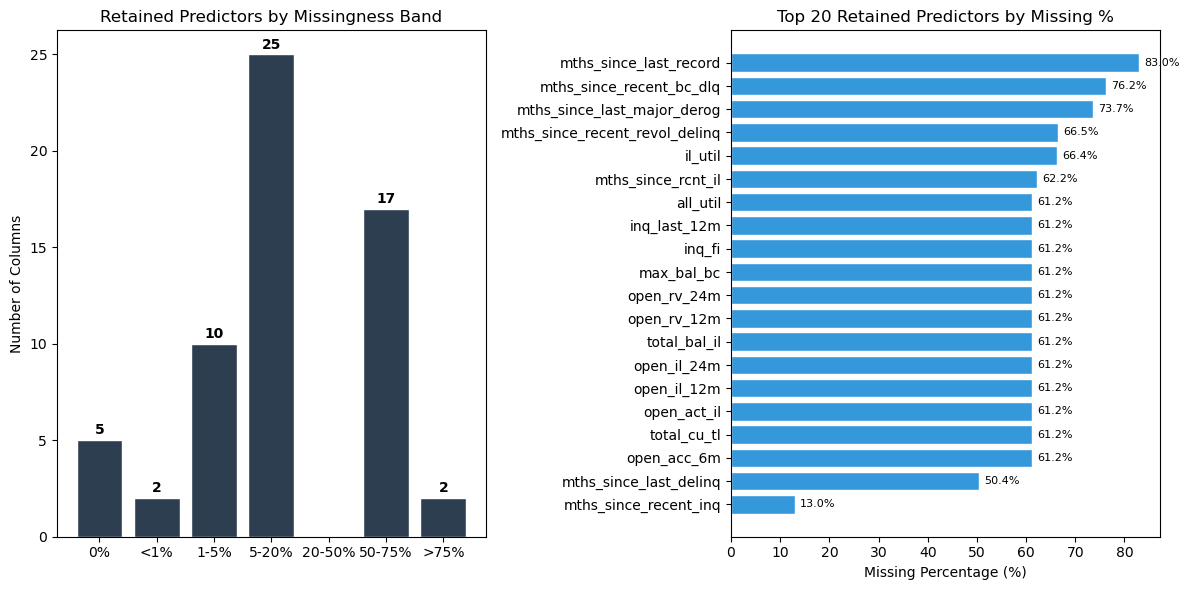

In [33]:
# Visualise missing value patterns
# 1. Distribution of missing percentages across retained predictors
# 2. Top retained predictors by missing percentage

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Figure 1: Distribution of missing percentages across retained predictors

# Compute missing percentage for every retained predictor
# 'target' is excluded because it is the response variable, not a feature
all_missing_pcts = df_keep.drop(columns=['target']).isnull().mean() * 100

# Define percentage bands to group columns by missingness level
bins = [0, 0.01, 1, 5, 20, 50, 75, 100]
labels = ['0%', '<1%', '1-5%', '5-20%', '20-50%', '50-75%', '>75%']

# Assign each column to a missingness band
binned = pd.cut(all_missing_pcts, bins=bins, labels=labels, right=True)

# Count how many columns fall into each band
bin_counts = binned.value_counts().reindex(labels)

# Plot the number of columns in each missingness band
axes[0].bar(labels, bin_counts.values, color='#2c3e50', edgecolor='white')

# Add title and y-axis label
axes[0].set_title('Retained Predictors by Missingness Band')
axes[0].set_ylabel('Number of Columns')

# Annotate each bar with the number of columns in that band
for i, v in enumerate(bin_counts.values):
    if v > 0:
        axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')



# Figure 2: Top retained predictors by missing percentage
# Reuse missing_df if already created earlier; otherwise compute it here
missing = df_keep.drop(columns=['target']).isnull().sum()
missing_pct = (missing / len(df_keep) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Keep only columns with any missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]

# Select the top 20 most-missing retained predictors
top_missing = missing_df.head(20).sort_values('Missing %', ascending=True)

# Horizontal bar chart
axes[1].barh(
    top_missing.index,
    top_missing['Missing %'],
    color='#3498db',
    edgecolor='white'
)

axes[1].set_title('Top 20 Retained Predictors by Missing %')
axes[1].set_xlabel('Missing Percentage (%)')

# Add percentage labels to bars
for i, v in enumerate(top_missing['Missing %']):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()

# Save and display
output_path = os.path.join(OUTPUT_DIR, "missing_patterns.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

### 4.3 Suspicious values requiring later preprocessing

In [34]:
# Simple suspicious-value audit for selected variables
quality_checks = {}

if 'dti' in df_keep.columns:
    quality_checks['dti < 0'] = int((df_keep['dti'] < 0).sum())
    quality_checks['dti == 999'] = int((df_keep['dti'] == 999).sum())

if 'annual_inc' in df_keep.columns:
    quality_checks['annual_inc <= 0'] = int((df_keep['annual_inc'] <= 0).sum())

if 'revol_util' in df_keep.columns:
    quality_checks['revol_util > 100'] = int((df_keep['revol_util'] > 100).sum())

if 'int_rate' in df_keep.columns:
    quality_checks['int_rate <= 0'] = int((df_keep['int_rate'] <= 0).sum())

quality_df = (
    pd.DataFrame(list(quality_checks.items()), columns=['Check', 'Count'])
    .sort_values('Count', ascending=False)
    .reset_index(drop=True)
)

quality_df

,Check,Count
0,revol_util > 100,4611
1,dti < 0,1
2,dti == 999,0
3,annual_inc <= 0,0
4,int_rate <= 0,0


## 5. Final modelling base table

`df_keep` is the retained base table that will be passed into Notebook 2.

A few notes on scope:

- `issue_d` is intentionally retained because it is needed for the out-of-time split in Notebook 2 and later to derive `credit_age_months` in Notebook 3. It should not be used as a raw predictor in the final model.
- `earliest_cr_line` is also retained at this stage because it will later be combined with `issue_d` to derive `credit_age_months`.
- `zip_code` has been reduced to `zip3`, and the raw `zip_code` field has been dropped.
- Missing-value treatment, encoding, scaling, target encoding, and other train-fitted preprocessing steps are deferred until after the out-of-time split.

The output of Notebook 1 is therefore a retained modelling base table rather than a final feature matrix.

In [35]:
print(f"Retained modelling dataset shape: {df_keep.shape[0]:,} rows x {df_keep.shape[1]:,} columns")
df_keep.head()

Retained modelling dataset shape: 1,319,544 rows x 85 columns


,loan_amnt,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,target,zip3,fico_avg
0,3600.0,36 months,13.99,123.03,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,debt_consolidation,PA,5.91,0.0,Aug-2003,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.0,30.0,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,0,190,677.0
1,24700.0,36 months,11.99,820.28,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,small_business,SD,16.06,1.0,Dec-1999,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.0,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,0,577,717.0
4,10400.0,60 months,22.45,289.91,F1,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,major_purchase,PA,25.37,1.0,Jun-1998,3.0,12.0,NaN,12.0,0.0,21929.0,64.5,35.0,w,0.0,NaN,0.0,0.0,331730.0,1.0,3.0,0.0,3.0,14.0,73839.0,84.0,4.0,7.0,9702.0,78.0,34000.0,2.0,1.0,3.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,12.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,0,174,697.0
5,11950.0,36 months,13.44,405.18,C3,4 years,RENT,34000.0,Source Verified,Dec-2015,debt_consolidation,GA,10.20,0.0,Oct-1987,0.0,NaN,NaN,5.0,0.0,8822.0,68.4,6.0,w,0.0,NaN,0.0,0.0,12798.0,0.0,1.0,0.0,0.0,338.0,3976.0,99.0,0.0,0.0,4522.0,76.0,12900.0,0.0,0.0,0.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,NaN,NaN,NaN,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,Cash,0,300,692.0
6,20000.0,36 months,9.17,637.58,B2,10+ years,MORTGAGE,180000.0,Not Verified,Dec-2015,debt_consolidation,MN,14.67,0.0,Jun-1990,0.0,49.0,NaN,12.0,0.0,87329.0,84.5,27.0,f,0.0,NaN,0.0,0.0,360358.0,0.0,2.0,0.0,2.0,18.0,29433.0,63.0,2.0,3.0,13048.0,74.0,94200.0,1.0,0.0,1.0,6.0,30030.0,0.0,102.9,0.0,0.0,142.0,306.0,10.0,10.0,4.0,12.0,NaN,10.0,NaN,0.0,4.0,6.0,4.0,5.0,7.0,9.0,16.0,6.0,12.0,0.0,0.0,0.0,2.0,96.3,100.0,0.0,0.0,388852.0,116762.0,31500.0,46452.0,Cash,0,550,682.0


In [36]:
output_dir = "../data/interim"
os.makedirs(output_dir, exist_ok=True)

# Final predictor columns in the modelling base table
final_predictor_cols = [c for c in df_keep.columns if c != "target"]

# Final excluded columns = initial exclusions + redundancy-based drops
final_excluded_cols = sorted(set(all_excluded).union(set(drop_due_to_redundancy)))

# Save retained base table
df_keep.to_csv(os.path.join(output_dir, "modelling_base_table.csv"), index=False)

# Save final column lists
with open(os.path.join(output_dir, "predictor_cols_notebook_1.pkl"), "wb") as f:
    pickle.dump(final_predictor_cols, f)

with open(os.path.join(output_dir, "excluded_cols_notebook_1.pkl"), "wb") as f:
    pickle.dump(final_excluded_cols, f)

# Save redundancy drops separately for documenta
with open(os.path.join(output_dir, "redundancy_dropped_cols_notebook_1.pkl"), "wb") as f:
    pickle.dump(drop_due_to_redundancy, f)

**Notebook 01 is now complete.** The main outputs and conclusions are:

1. The modelling population has been restricted to accepted individual loans with resolved outcomes.
2. The target is defined as:
   - `Fully Paid = 0`
   - `Charged Off = 1`
3. Clear post-origination leakage columns have been excluded, including repayment, recovery, hardship, settlement, and refreshed-credit fields.
4. Joint-application fields were excluded because this analysis focuses on the individual-loan segment.
5. Several redundant columns were simplified or dropped, including:
   - `grade` in favour of `sub_grade`
   - `fico_range_low` and `fico_range_high` in favour of `fico_avg`
   - `funded_amnt` and `funded_amnt_inv` in favour of `loan_amnt`
   - `zip_code` in favour of `zip3`
6. Missingness is substantial in several bureau-related variables and appears to be structured rather than random.
7. Selected numeric variables contain suspicious values and will require explicit treatment in later preprocessing.

The retained modelling base table is now ready for out-of-time splitting and training-only EDA in Notebook 2